# OPENING NOTES
The core focus of this experimentation notebook is improving the generalisation of the RAF-DB images. The key problems I noticed with my previous implementation were:
- RAF-DB and FER2013's test sets were using the same data augmentations. This is troublesome as RAF-DB is another in-the-wild dataset with its own resolution and dataset-independent format. I need to analyse why exactly the translation to this unseen dataset is especially difficult
- Uncertainty is not being quantified, which is needed in foreign data.
- Timm's `SwinTransformerBlock` is currently a black box to me, although I am evidently replacing the only part of it that allows for Swin-Xception to take effect (replacing the MLP head with a DS-FFN). I will take this notebook to identify if any further components could use adjustments befitting of my experiment

# KEY CHANGES
- Examine key errors when classifying RAF-DB [x]
- Predict with uncertainty estimation using MCDO [x]
- Swin-Tiny's Embedding and head count [x]
- Adding Maximum Mean Discrepancy for RAF-DB Domain Adaptation [x]

# 0. Import all core dependencies

In [ ]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import timm
from timm.models.swin_transformer import SwinTransformerBlock

# Optimisers and Schedulers
from torch.optim import AdamW, RMSprop, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, StepLR

# Data Handling
from PIL import Image
import numpy as np
import pandas as pd
import cv2

# Data Visualisation - TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Class Imbalance Handling - TODO
from imblearn.over_sampling import SMOTE
from collections import Counter

# Evaluation - TODO
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)

# Utilities
from tqdm import tqdm
from einops import rearrange
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Locate source helper files
NOTEBOOK_DIR = os.getcwd()

SRC_PATH = os.path.abspath("../../src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from datasets import FERDataset
from torchvision.transforms import v2

# Reproducibility
import random
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configure PyTorch to use my GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

C:\Users\aria_\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda


# 1. Define all modules in Swin-Xception

## 1.1 Patch Embedding Block

In [2]:
class PatchEmbedding(nn.Module):
    def __init__(self,
                 in_channels:int=3,
                 dim:int=96,
                 patch_size:int=4):
        super(PatchEmbedding, self).__init__()

        self.patch_size = patch_size
        self.dim = dim

        self.patcher = nn.Conv2d(in_channels=in_channels, out_channels=dim, kernel_size=patch_size, stride=patch_size, padding=0)

        self.flatten = nn.Flatten(start_dim=2, end_dim=3)

        self.norm = nn.LayerNorm(dim)

    def forward(self, x):

        image_resolution = x.shape[-1]

        assert image_resolution % self.patch_size == 0, \
            f"Input image size must be divisible by patch size, \
            image shape: {image_resolution}, patch size: {self.patch_size}"
        
        x_patched = self.patcher(x)

        x_flattened = self.flatten(x_patched)

        x = x_flattened.permute(0,2,1)

        x = self.norm(x)

        return x

## 1.2 Patch Merging Block

In [3]:
class PatchMerging(nn.Module):
    def __init__(self, dim):
        super(PatchMerging, self).__init__()

        self.dim = dim

        self.reduction = nn.Linear(4*dim, 2*dim, bias=False)

        self.norm = nn.LayerNorm(4*dim)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        assert H % 2 == 0 and W % 2 == 0, f"H and W must be even, got H={H}, W={W}"

        x = x.view(B, H, W, C)

        x0 = x[:, 0::2, 0::2, :]
        x1 = x[:, 1::2, 0::2, :]
        x2 = x[:, 0::2, 1::2, :]
        x3 = x[:, 1::2, 1::2, :]

        x = torch.cat([x0,x1,x2,x3], dim=-1)

        x = x.view(B, -1, 4*C)

        x = self.norm(x)

        x = self.reduction(x)

        return x

## 1.3 Depthwise Separable Convolution (The Xception side)

In [4]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size:int=3):
        super(DepthwiseSeparableConv, self).__init__()

        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, padding=kernel_size//2, groups=in_channels)
        
        self.gelu = nn.GELU()

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x):

        x = self.depthwise(x)

        x = self.gelu(x)

        x = self.pointwise(x)

        return x
    

## 1.4 Depthwise Separable FFN (Replaces MLP Head of Swin Block)

In [5]:
class DepthwiseSeparableFFN(nn.Module):
    def __init__(self,
                 dim,
                 mlp_ratio:int=8,
                 dropout:float=0.4):
        super(DepthwiseSeparableFFN, self).__init__()

        hidden_dim = int(dim * mlp_ratio)

        self.depthwise1 = DepthwiseSeparableConv(dim, hidden_dim, kernel_size=3)

        self.dropout1 = nn.Dropout(dropout)

        self.depthwise2 = DepthwiseSeparableConv(hidden_dim, dim, kernel_size=3)

        self.dropout2 = nn.Dropout(dropout)

    def forward(self, x):

        B, N, C = x.shape

        H = W = int(np.sqrt(N))

        x = x.transpose(1, 2).reshape(B, C, H, W)

        x = self.depthwise1(x)

        x = self.dropout1(x)

        x = self.depthwise2(x)

        x = self.dropout2(x)

        x = x.reshape(B, C, N).transpose(1, 2)

        return x

## 1.5 Swin-Xception Block

In [6]:
class SwinXceptionBlock(nn.Module):
    """Swin Transformer block that uses depthwise separable FFN instead of an MLP"""
    def __init__(self,
                 embedding_dim,
                 num_heads,
                 input_resolution,
                 window_size:int=7,
                 shift_size:int=0,
                 mlp_ratio:int=8):
        super(SwinXceptionBlock, self).__init__()

        from timm.models.swin_transformer import SwinTransformerBlock

        self.block = SwinTransformerBlock( # Use timm's Swin Transformer Block...
            dim=embedding_dim,
            input_resolution=input_resolution,
            num_heads=num_heads,
            window_size=window_size,
            shift_size=shift_size,
            mlp_ratio=mlp_ratio,
            proj_drop=0.1,
            drop_path=0.1
        )

        self.input_resolution = input_resolution

        self.block.mlp = DepthwiseSeparableFFN(embedding_dim, mlp_ratio) # But replace the mlp head with my DS-FFN

    def forward(self, x): # X input is sequential transformer data
        B, N, C = x.shape

        H, W = self.input_resolution # height and width

        x = x.view(B, H, W, C)

        # Swin blocks accept inputs as spatial grid
        x = self.block(x)

        # back to sequential data
        x = x.view(B, N, C)
        
        return x

## 1.6 Swin-Xception Backbone

In [7]:
class SwinXception(nn.Module):
    def __init__(self, num_classes:int=7, dropout:float=0.5):
        super(SwinXception, self).__init__()

        self.patch_embed = PatchEmbedding(in_channels=3, dim=96, patch_size=4)

        self.layer1 = nn.ModuleList([SwinXceptionBlock(96, num_heads=3, input_resolution=(56, 56), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge1 = PatchMerging(96) # Reduce dimensions, increase channels

        self.layer2 = nn.ModuleList([SwinXceptionBlock(192, num_heads=6, input_resolution=(28, 28), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])
        self.merge2 = PatchMerging(192)

        self.layer3 = nn.ModuleList([SwinXceptionBlock(384, num_heads=12, input_resolution=(14, 14), shift_size=0 if i % 2 == 0 else 3) for i in range(6)])
        self.merge3 = PatchMerging(384)

        self.layer4 = nn.ModuleList([SwinXceptionBlock(768, num_heads=24, input_resolution=(7, 7), shift_size=0 if i % 2 == 0 else 3) for i in range(2)])

        self.norm = nn.LayerNorm(768)
        
        self.avgpool1d = nn.AdaptiveAvgPool1d(output_size=1)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(768, num_classes)
        )

    def forward(self, x):

        x = self.patch_embed(x)

        for block in self.layer1:
            x = block(x)
        x = self.merge1(x)

        for block in self.layer2:
            x = block(x)
        x = self.merge2(x)

        for block in self.layer3:
            x = block(x)
        x = self.merge3(x)

        for block in self.layer4:
            x = block(x)

        x = self.norm(x)
        x = x.transpose(1, 2)
        x = self.avgpool1d(x)
        x = torch.flatten(x, 1)
        x = self.head(x)

        return x

    def monte_carlo_dropout_predict(self, x, n_samples=10):
        self.train()
        predictions = []

        with torch.no_grad():
            for _ in range(n_samples):
                predictions.append(torch.softmax(self(x), dim=1))

        predictions = torch.stack(predictions)
        mean_pred = predictions.mean(dim=0)
        uncertainty = predictions.std(dim=0)

        return mean_pred, uncertainty

# 2. Image Preprocessing function

In [8]:
transform_train = v2.Compose([
    v2.RandomAffine(degrees=10, scale=(0.8, 1.0), translate=(0.1, 0.1), interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.Resize(size=(224, 224), antialias=True), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.Resize(size=(232, 232), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.CenterCrop(size=(224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

fer_train = FERDataset(os.path.abspath("../../datasets/FER2013/train"), transform_train)
fer_test = FERDataset(os.path.abspath("../../datasets/FER2013/test"), transform_test)
raf_test = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/test"), transform_test)

train_loader = DataLoader(fer_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
test_fer_loader = DataLoader(fer_test, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_raf_loader = DataLoader(raf_test, batch_size=32,shuffle=False, num_workers=4, pin_memory=True)

print(f"FER2013 Training set images: {len(fer_train)}")
print(f"FER2013 Test set images: {len(fer_test)}")
print(f"RAF-DB Test set images: {len(raf_test)}")

FER2013 Training set images: 28709
FER2013 Test set images: 7178
RAF-DB Test set images: 3068


# 3. Stage 1: End-to-End Student Training

## 3.1 Train Functions

### 3.1.1 Baseline Train Function

In [9]:
def train_one_epoch(model, data_loader, criterion, optimiser, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(data_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct * 100. / total
    return epoch_loss, epoch_acc

### 3.1.2 Train Function with MMD

In [10]:
def mmd_loss (source_features, target_features, kernel='rbf'):
    """
    Maximum Mean Discrepancy loss
    Measures distribution distance between source and target features
    """
    def gaussian_kernel(x, y, sigma=1.0):
        dist = torch.cdist(x, y, p=2)
        return torch.exp(-dist**2 / (2* sigma**2))

    K_ss = gaussian_kernel(source_features, source_features).mean()
    K_tt = gaussian_kernel(target_features, target_features).mean()
    K_st = gaussian_kernel(source_features, target_features).mean()

    return K_ss + K_tt - 2 * K_st


def extract_features_single_batch(model, images):
    """Extract features from a single batch (for domain adaptation)"""
    x = model.patch_embed(images)

    for block in model.layer1:
        x = block(x)
    x = model.merge1(x)
    
    for block in model.layer2:
        x = block(x)
    x = model.merge2(x)
    
    for block in model.layer3:
        x = block(x)
    x = model.merge3(x)
    
    for block in model.layer4:
        x = block(x)

    x = model.norm(x)
    x = x.transpose(1, 2)
    x = model.avgpool1d(x)
    x = torch.flatten(x, 1)

    return x
    

def train_with_mmd(model, source_loader, target_loader, source_test_loader, target_test_loader,
                   num_epochs=20, device='cuda', mmd_weight=0.1):
    """
    Train with MMD and monitor performance on both datasets
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
    criterion_cls = nn.CrossEntropyLoss()
    
    for epoch in range(num_epochs):
        model.train()
        source_iter = iter(source_loader)
        target_iter = iter(target_loader)
        
        num_batches = min(len(source_loader), len(target_loader))
        running_cls_loss = 0.0
        running_mmd = 0.0
        
        for batch_idx in tqdm(range(num_batches), desc=f"Epoch {epoch+1}/{num_epochs}"):
            try:
                source_images, source_labels = next(source_iter)
            except StopIteration:
                source_iter = iter(source_loader)
                source_images, source_labels = next(source_iter)
            
            try:
                target_images, _ = next(target_iter)
            except StopIteration:
                target_iter = iter(target_loader)
                target_images, _ = next(target_iter)
            
            min_batch_size = min(source_images.size(0), target_images.size(0))
            source_images = source_images[:min_batch_size].to(device)
            source_labels = source_labels[:min_batch_size].to(device)
            target_images = target_images[:min_batch_size].to(device)
            
            optimizer.zero_grad()
            
            # Extract features
            source_features = extract_features_single_batch(model, source_images)
            
            with torch.no_grad():
                target_features = extract_features_single_batch(model, target_images)
            
            # Classification loss
            source_output = model.head(source_features)
            cls_loss = criterion_cls(source_output, source_labels)
            
            # MMD loss
            mmd = mmd_loss(source_features, target_features.detach())
            
            total_loss = cls_loss + mmd_weight * mmd
            total_loss.backward()
            optimizer.step()
            
            running_cls_loss += cls_loss.item()
            running_mmd += mmd.item()
            
            if batch_idx % 50 == 0:
                torch.cuda.empty_cache()
        
        # Epoch summary
        avg_cls_loss = running_cls_loss / num_batches
        avg_mmd = running_mmd / num_batches
        
        # Validate on both datasets
        print(f"\nEpoch {epoch+1} Training:")
        print(f"  Cls Loss: {avg_cls_loss:.4f}, MMD: {avg_mmd:.4f}")
        
        # Test on FER2013 (source domain)
        fer_loss, fer_acc = validate(model, source_test_loader, criterion_cls, device)
        print(f"  FER2013 Test Acc: {fer_acc:.2f}%")
        
        # Test on RAF-DB (target domain) - THIS IS THE KEY METRIC
        raf_loss, raf_acc = validate(model, target_test_loader, criterion_cls, device)
        print(f"  RAF-DB Test Acc: {raf_acc:.2f}% ← Target domain performance")
        print("-" * 60)

## 3.2 Validation Function

In [11]:
def validate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(data_loader)
    val_acc = correct * 100. / total
    
    return val_loss, val_acc

## 3.3 Training and Validation from source domain

### 3.3.1 Set up my model

In [13]:
PATH = "model_checkpoints/latest.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 75

model = SwinXception(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss()
optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimiser, T_max=epochs, eta_min=1e-6)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No student model checkpoints found. Starting from epoch 1...")

Checkpoint found! Starting from epoch 51...


In [13]:
if start_epoch == 0:
    # Freeze backbone, train only head (Epochs 1-3)
    # This aligns the random head with the pre-trained body without wrecking the body
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters(): # ResNet's head is called 'fc'
        param.requires_grad = True
        
    print("Warming up head (3 Epochs)...")
    # Use Adam for quick head alignment
    warmup_optim = AdamW(model.head.parameters(), lr=3e-3)
    
    for epoch in range(3):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            warmup_optim.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            warmup_optim.step()

    # Unfreeze and Train All (Epochs 4-30)
    print("Fine-tuning entire model...")
    for param in model.parameters():
        param.requires_grad = True

for epoch in range(start_epoch, epochs):
    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    
    print("Training on FER2013...")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)

    print("Testing on FER2013...")
    fer_loss, fer_acc = validate(model, test_fer_loader, criterion, device)

    print("Testing of RAF-DB...")
    raf_loss, raf_acc = validate(model, test_raf_loader, criterion, device)
    
    scheduler.step()

    print(f"FER2013 Training | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"FER2013 Testing  | Loss: {fer_loss:.4f} | Accuracy: {fer_acc:.2f}%")
    print(f"RAF-DB Testing   | Loss: {raf_loss:.4f} | Accuracy: {raf_acc:.2f}%")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimiser_state_dict": optimiser.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, PATH)
    
print("="*60)
torch.save(model.state_dict(), 'swin_xception_baseline.pth')

Warming up head (3 Epochs)...


Warmup 3: 100%|██████████████████████████████████████████████████████████████████████| 898/898 [02:00<00:00,  7.42it/s]


Fine-tuning entire model...
Epoch 1/75
Training on FER2013...


100%|████████████████████████████████████████████████████████████████████████████████| 898/898 [06:11<00:00,  2.42it/s]


Testing on FER2013...


...

Testing of RAF-DB...


100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [00:18<00:00,  5.33it/s]


FER2013 Training | Loss: 0.8415 | Accuracy: 68.37%
FER2013 Testing  | Loss: 0.9778 | Accuracy: 65.00%
RAF-DB Testing   | Loss: 2.4574 | Accuracy: 28.75%
Epoch 52/75
Training on FER2013...


 75%|███████████████████████████████████████████████████████████▋                    | 670/898 [04:35<01:33,  2.43it/s]


KeyboardInterrupt: 

Save an interrupted model:

In [14]:
torch.save(model.state_dict(), 'swin_xception_baseline.pth')

Load a baseline model:

In [12]:
model = SwinXception(num_classes=7).to(device)

swin_xception_baseline = torch.load('swin_xception_baseline.pth', map_location=device)

model.load_state_dict(swin_xception_baseline)
print(f"Base SwinXception model loaded!")

Base SwinXception model loaded!


## Use a train-test-val split for remaining steps

In [16]:
train_size = int(0.8 * len(fer_train))
val_size = len(fer_train) - train_size

fer_train, fer_val = torch.utils.data.random_split(fer_train, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))
print("Now proceeding with an 80:20 split for the FER train set...")

Now proceeding with an 80:20 split for the FER train set...


## 3.4 Domain Adaptation to RAF-DB

In [23]:
train_loader_mmd = DataLoader(fer_train, batch_size=16, shuffle=True, num_workers=4, pin_memory=True)
test_fer_loader_mmd = DataLoader(fer_test, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)
test_raf_loader_mmd = DataLoader(raf_test, batch_size=16, shuffle=False, num_workers=4, pin_memory=True)

train_with_mmd(
    model,
    source_loader=train_loader_mmd,           # FER2013 train
    target_loader=test_raf_loader_mmd,        # RAF-DB test (for adaptation)
    source_test_loader=test_fer_loader_mmd,   # FER2013 test (for monitoring)
    target_test_loader=test_raf_loader_mmd,   # RAF-DB test (for monitoring)
    num_epochs=30,
    device=device,
    mmd_weight=0.5
)

torch.save(model.state_dict(), 'swin_xception_mmd_adapted.pth')

Epoch 1/30: 100%|████████████████████████████████████████████████████████████████████| 192/192 [00:46<00:00,  4.12it/s]



Epoch 1 Training:
  Cls Loss: 0.9703, MMD: 0.1297


100%|████████████████████████████████████████████████████████████████████████████████| 449/449 [00:36<00:00, 12.29it/s]


  FER2013 Test Acc: 60.16%


100%|████████████████████████████████████████████████████████████████████████████████| 192/192 [00:18<00:00, 10.38it/s]


...

  FER2013 Test Acc: 61.47%


100%|████████████████████████████████████████████████████████████████████████████████| 192/192 [00:20<00:00,  9.53it/s]


  RAF-DB Test Acc: 23.14% ← Target domain performance
------------------------------------------------------------


Epoch 11/30:  17%|███████████▋                                                        | 33/192 [00:08<00:41,  3.87it/s]


KeyboardInterrupt: 

# 4. Evaluation and Metrics, Initial training

## 4.1 Confusion matrix

### 4.1.1 Run one evaluation to get all predictions

In [13]:
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Getting predictions"):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

### 4.1.2 Plotting the confusion matrices

In [14]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'{title} - Raw Counts')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # Percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'{title} - Percentages (%)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    
    plt.show()

### 4.1.3 Detailed metrics

In [15]:
def print_detailed_metrics(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    print("\nPer-Class Accuracy:")
    for i, (class_name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f"{class_name:12s}: {acc:6.2f}%")
    
    # Overall accuracy
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"\nOverall Accuracy: {overall_acc:.2f}%")

### 4.1.4 Generate Matrices


Generating Confusion Matrices and Metrics

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:38<00:00,  5.82it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


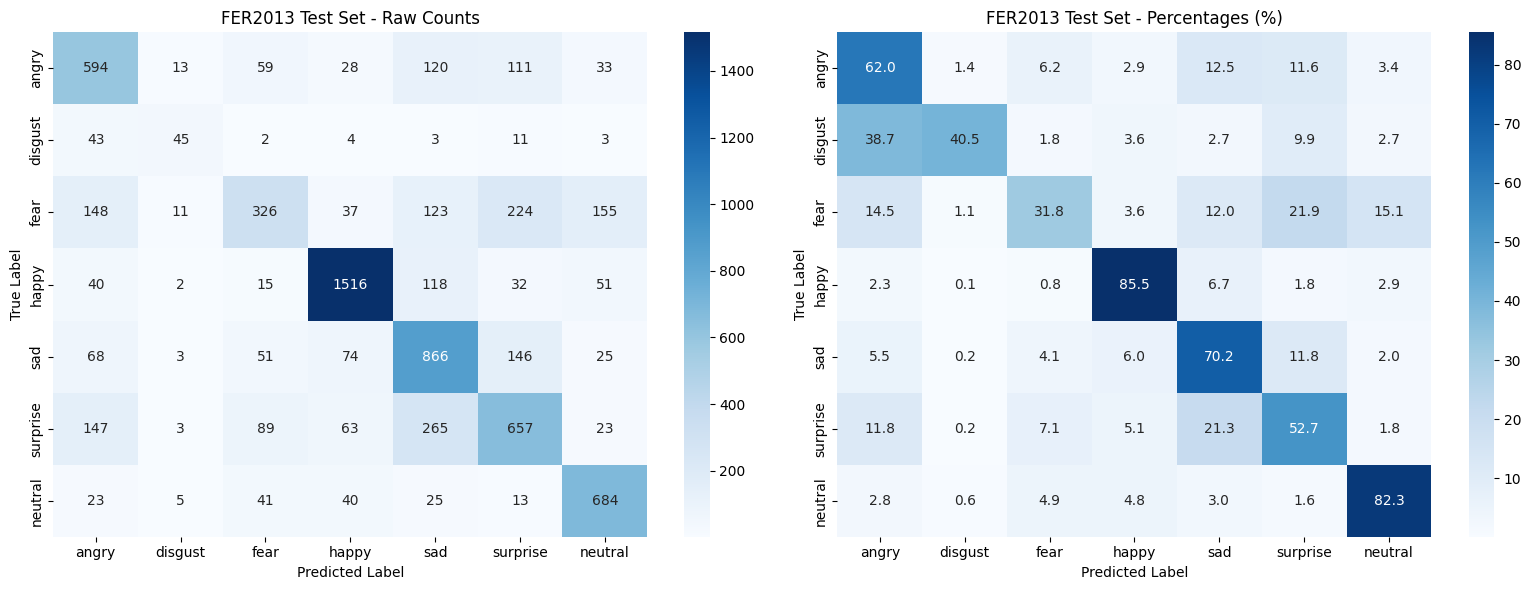


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.5588    0.6200    0.5878       958
     disgust     0.5488    0.4054    0.4663       111
        fear     0.5592    0.3184    0.4057      1024
       happy     0.8604    0.8546    0.8575      1774
         sad     0.5697    0.7024    0.6291      1233
    surprise     0.5503    0.5269    0.5383      1247
     neutral     0.7023    0.8231    0.7579       831

    accuracy                         0.6531      7178
   macro avg     0.6213    0.6072    0.6061      7178
weighted avg     0.6502    0.6531    0.6448      7178


Per-Class Accuracy:
angry       :  62.00%
disgust     :  40.54%
fear        :  31.84%
happy       :  85.46%
sad         :  70.24%
surprise    :  52.69%
neutral     :  82.31%

Overall Accuracy: 65.31%

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:21<00:00,  4.50it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


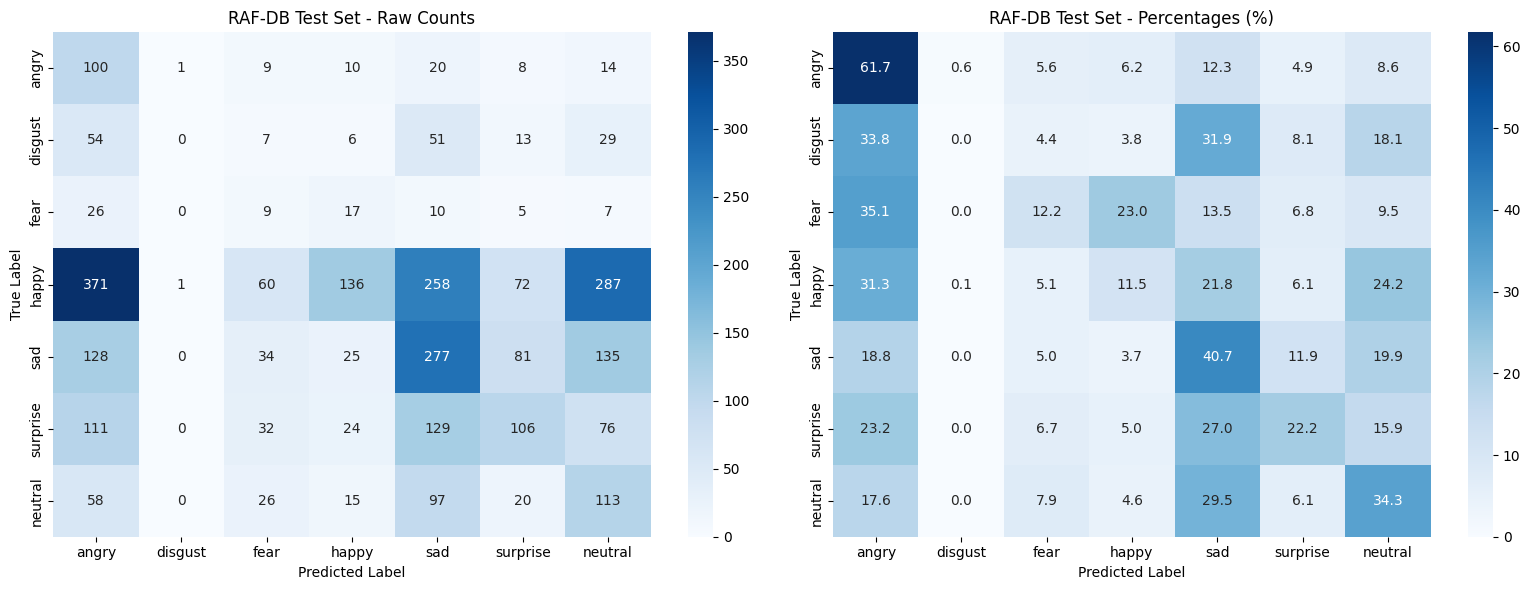


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.1179    0.6173    0.1980       162
     disgust     0.0000    0.0000    0.0000       160
        fear     0.0508    0.1216    0.0717        74
       happy     0.5837    0.1148    0.1918      1185
         sad     0.3290    0.4074    0.3640       680
    surprise     0.3475    0.2218    0.2708       478
     neutral     0.1710    0.3435    0.2283       329

    accuracy                         0.2415      3068
   macro avg     0.2286    0.2609    0.1892      3068
weighted avg     0.3783    0.2415    0.2336      3068


Per-Class Accuracy:
angry       :  61.73%
disgust     :   0.00%
fear        :  12.16%
happy       :  11.48%
sad         :  40.74%
surprise    :  22.18%
neutral     :  34.35%

Overall Accuracy: 24.15%


In [16]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

### 4.1.5 Compare Minority class performance

In [17]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    fer_mask = fer_labels == cls_idx
    raf_mask = raf_labels == cls_idx
    
    if fer_mask.sum() > 0:
        fer_acc = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize()} - FER2013: {fer_acc:.2f}% ({fer_mask.sum()} samples)")
    
    if raf_mask.sum() > 0:
        raf_acc = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize()} - RAF-DB:  {raf_acc:.2f}% ({raf_mask.sum()} samples)")
    print()


Minority Class Performance (Disgust & Fear)
Disgust - FER2013: 40.54% (111 samples)
Disgust - RAF-DB:  0.00% (160 samples)

Fear - FER2013: 31.84% (1024 samples)
Fear - RAF-DB:  12.16% (74 samples)



## 4.2 UAR and WAR

### 4.2.1 UAR and WAR calculation

In [18]:
def calculate_uar_war(y_true, y_pred, class_names):
    """
    Calculate UAR and WAR metrics
    
    UAR (Unweighted Average Recall): Mean of per-class recalls (treats all classes equally)
    WAR (Weighted Average Recall): Weighted mean of per-class recalls (weighted by class frequency)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class recall (same as per-class accuracy for single-label classification)
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    
    # UAR: Simple average of all class recalls
    uar = np.mean(per_class_recall) * 100
    
    # WAR: Weighted average by class support
    class_support = cm.sum(axis=1)
    war = np.average(per_class_recall, weights=class_support) * 100
    
    return uar, war, per_class_recall

### 4.2.2 Detailed metrics with UAR and WAR

In [19]:
def print_detailed_metrics_with_uar_war(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics including UAR and WAR"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    
    # Standard classification report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Calculate UAR and WAR
    uar, war, per_class_recall = calculate_uar_war(y_true, y_pred, class_names)
    
    print("\n" + "-"*60)
    print("Per-Class Recall (%):")
    print("-"*60)
    for class_name, recall in zip(class_names, per_class_recall):
        print(f"{class_name:12s}: {recall*100:6.2f}%")
    
    print("\n" + "-"*60)
    print("Summary Metrics:")
    print("-"*60)
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"Overall Accuracy: {overall_acc:.2f}%")
    print(f"WAR (Weighted Average Recall): {war:.2f}%")
    print(f"UAR (Unweighted Average Recall): {uar:.2f}%")
    print("-"*60)

### 4.2.3 Generate confusion matrices for test sets with UAR and WAR


Generating Confusion Matrices and Metrics

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:32<00:00,  6.91it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


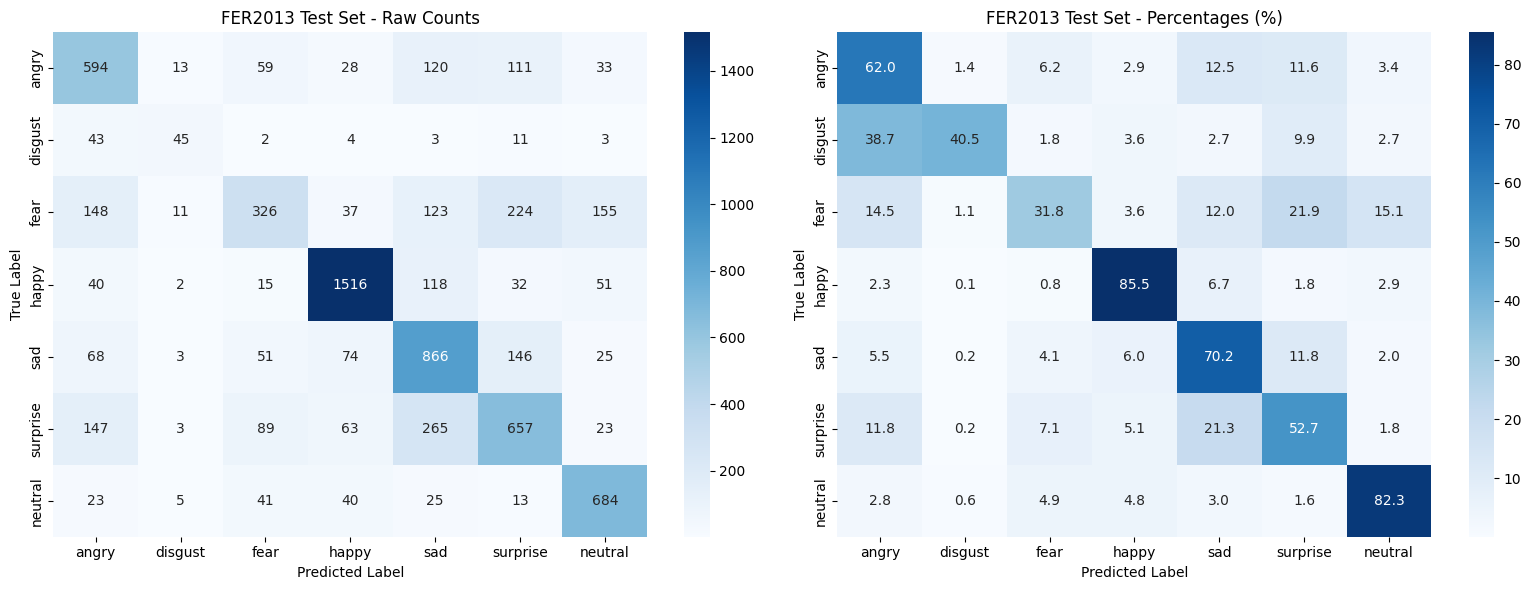


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.5588    0.6200    0.5878       958
     disgust     0.5488    0.4054    0.4663       111
        fear     0.5592    0.3184    0.4057      1024
       happy     0.8604    0.8546    0.8575      1774
         sad     0.5697    0.7024    0.6291      1233
    surprise     0.5503    0.5269    0.5383      1247
     neutral     0.7023    0.8231    0.7579       831

    accuracy                         0.6531      7178
   macro avg     0.6213    0.6072    0.6061      7178
weighted avg     0.6502    0.6531    0.6448      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  62.00%
disgust     :  40.54%
fear        :  31.84%
happy       :  85.46%
sad         :  70.24%
surprise    :  52.69%
neutral     :  82.31%

------------------------------------------------------------
Summary Metric

Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:18<00:00,  5.25it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


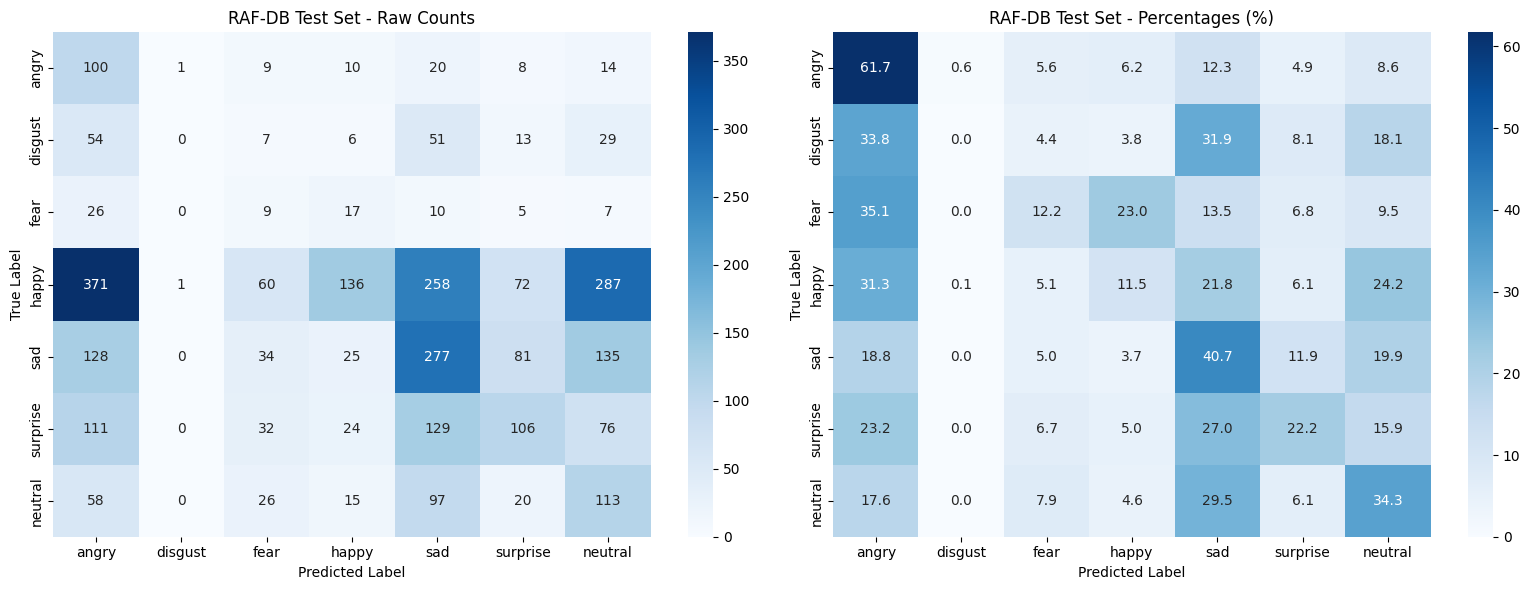


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.1179    0.6173    0.1980       162
     disgust     0.0000    0.0000    0.0000       160
        fear     0.0508    0.1216    0.0717        74
       happy     0.5837    0.1148    0.1918      1185
         sad     0.3290    0.4074    0.3640       680
    surprise     0.3475    0.2218    0.2708       478
     neutral     0.1710    0.3435    0.2283       329

    accuracy                         0.2415      3068
   macro avg     0.2286    0.2609    0.1892      3068
weighted avg     0.3783    0.2415    0.2336      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  61.73%
disgust     :   0.00%
fear        :  12.16%
happy       :  11.48%
sad         :  40.74%
surprise    :  22.18%
neutral     :  34.35%

------------------------------------------------------------
Summary Metrics

In [20]:
print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

### 4.2.4 Summary Comparison Table

In [21]:
print("\n" + "="*60)
print("Cross-Dataset Performance Summary")
print("="*60)

fer_uar, fer_war, _ = calculate_uar_war(fer_labels, fer_preds, emotions)
raf_uar, raf_war, _ = calculate_uar_war(raf_labels, raf_preds, emotions)

fer_acc = (fer_preds == fer_labels).sum() / len(fer_labels) * 100
raf_acc = (raf_preds == raf_labels).sum() / len(raf_labels) * 100

print(f"\n{'Metric':<30} {'FER2013':>12} {'RAF-DB':>12}")
print("-"*60)
print(f"{'Overall Accuracy':<30} {fer_acc:>11.2f}% {raf_acc:>11.2f}%")
print(f"{'WAR (Weighted Avg Recall)':<30} {fer_war:>11.2f}% {raf_war:>11.2f}%")
print(f"{'UAR (Unweighted Avg Recall)':<30} {fer_uar:>11.2f}% {raf_uar:>11.2f}%")
print("-"*60)


Cross-Dataset Performance Summary

Metric                              FER2013       RAF-DB
------------------------------------------------------------
Overall Accuracy                     65.31%       24.15%
WAR (Weighted Avg Recall)            65.31%       24.15%
UAR (Unweighted Avg Recall)          60.72%       26.09%
------------------------------------------------------------


### 4.2.5 Minority Class Performance with UAR and WAR

In [22]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

print(f"\n{'Class':<12} {'Dataset':<10} {'Recall':<10} {'Samples':<10}")
print("-"*60)

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    # FER2013
    fer_mask = fer_labels == cls_idx
    if fer_mask.sum() > 0:
        fer_recall = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'FER2013':<10} {fer_recall:>8.2f}% {fer_mask.sum():>9}")
    
    # RAF-DB
    raf_mask = raf_labels == cls_idx
    if raf_mask.sum() > 0:
        raf_recall = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'RAF-DB':<10} {raf_recall:>8.2f}% {raf_mask.sum():>9}")
    
    print()


Minority Class Performance (Disgust & Fear)

Class        Dataset    Recall     Samples   
------------------------------------------------------------
Disgust      FER2013       40.54%       111
Disgust      RAF-DB         0.00%       160

Fear         FER2013       31.84%      1024
Fear         RAF-DB        12.16%        74



# 5. Stage 2: Feature Extraction and Synthesis

## 5.1 Extract Features

In [23]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Features"):
            images = images.to(device)

            x = model.patch_embed(images)

            for block in model.layer1:
                x = block(x)
            x = model.merge1(x)

            for block in model.layer2:
                x = block(x)
            x = model.merge2(x)

            for block in model.layer3:
                x = block(x)
            x = model.merge3(x)
            
            for block in model.layer4:
                x = block(x)

            x = model.norm(x)
            x = x.transpose(1, 2)
            x = model.avgpool1d(x)
            x = torch.flatten(x, 1)

            all_features.append(x.cpu().numpy())
            all_labels.append(labels.numpy())

        features = np.vstack(all_features)
        labels = np.concatenate(all_labels)

        return features, labels

## 5.2 Apply SMOTE on extracted deep features

In [24]:
def apply_smote(features, labels, random_state=42):
    print("Original class distribution:")
    print(Counter(labels))
    
    smote = SMOTE(random_state=random_state, k_neighbors=5, sampling_strategy="minority")
    balanced_features, balanced_labels = smote.fit_resample(features, labels)

    print("Balanced class distribution:")
    print(Counter(balanced_labels))

    return balanced_features, balanced_labels

In [25]:
features, labels = extract_features(model, train_loader, device)
balanced_features, balanced_labels = apply_smote(features, labels)

Extracting Features: 100%|███████████████████████████████████████████████████████████| 898/898 [01:54<00:00,  7.87it/s]


Original class distribution:
Counter({np.int64(3): 7215, np.int64(4): 4965, np.int64(5): 4830, np.int64(2): 4097, np.int64(0): 3995, np.int64(6): 3171, np.int64(1): 436})
Balanced class distribution:
Counter({np.int64(5): 7215, np.int64(4): 7215, np.int64(3): 7215, np.int64(0): 7215, np.int64(2): 7215, np.int64(6): 7215, np.int64(1): 7215})


# 6. Stage 3: Retraining the MLP Head

In [30]:
def retrain_mlp_head(model, features, labels, device, epochs=20, batch_size=128, lr=1e-3, weight_decay=1e-3):
    # Freeze all params in Swin-X backbone
    for param in model.patch_embed.parameters():
        param.requires_grad = False
    for stage in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in stage:
            for param in block.parameters():
                param.requires_grad = False

    for merge in [model.merge1, model.merge2, model.merge3]:
        for param in merge.parameters():
            param.requires_grad = False

    for param in model.head.parameters():
        param.requires_grad = True

    features_tensor = torch.FloatTensor(features)
    labels_tensor = torch.LongTensor(labels)
    dataset = torch.utils.data.TensorDataset(features_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_features, batch_labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            optimiser.zero_grad()

            outputs = model.head(batch_features)

            loss = criterion(outputs, batch_labels)

            loss.backward()
            optimiser.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += batch_labels.size(0)
            correct += predicted.eq(batch_labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = correct * 100. / total

        print(f"Epoch {epoch+1}/{epochs}   Loss: {epoch_loss}   Accuracy: {epoch_acc}")

    return model

In [31]:
model = retrain_mlp_head(model, balanced_features, balanced_labels, device)

torch.save(model.state_dict(), 'swin_xception_final.pth')

Epoch 1/20: 100%|███████████████████████████████████████████████████████████████████| 395/395 [00:01<00:00, 253.20it/s]


Epoch 1/20   Loss: 0.7681750359414499   Accuracy: 71.28997128997129


Epoch 2/20: 100%|███████████████████████████████████████████████████████████████████| 395/395 [00:01<00:00, 258.13it/s]


Epoch 2/20   Loss: 0.7669302537471433   Accuracy: 71.2028512028512


Epoch 3/20: 100%|███████████████████████████████████████████████████████████████████| 395/395 [00:01<00:00, 263.45it/s]


...

Epoch 18/20   Loss: 0.7670419975172116   Accuracy: 71.43451143451144


Epoch 19/20: 100%|██████████████████████████████████████████████████████████████████| 395/395 [00:01<00:00, 251.41it/s]


Epoch 19/20   Loss: 0.7677885883971106   Accuracy: 71.15335115335115


Epoch 20/20: 100%|██████████████████████████████████████████████████████████████████| 395/395 [00:01<00:00, 265.13it/s]


Epoch 20/20   Loss: 0.7670674574526051   Accuracy: 71.32363132363132


In [33]:
model = SwinXception(num_classes=7).to(device)

swin_xception_final = torch.load('swin_xception_final.pth', map_location=device)

model.load_state_dict(swin_xception_final)
print(f"Post-SMOTE SwinXception model loaded!")

Post-SMOTE SwinXception model loaded!


# 7. Evaluation Metrics and Visualisation on Balanced set

## 7.1 Validate Loss and Accuracy on Test sets

In [35]:
fer_loss, fer_acc = validate(model, test_fer_loader, nn.CrossEntropyLoss(), device)
raf_loss, raf_acc = validate(model, test_raf_loader, nn.CrossEntropyLoss(), device)

print(f"FER2013 | new loss: {fer_loss:.4f} | new accuracy: {fer_acc:.2f}")
print(f"RAF-DB | new loss: {raf_loss:.4f} | new accuracy: {raf_acc:.2f}")

100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [00:18<00:00,  5.23it/s]

FER2013 | new loss: 0.9879 | new accuracy: 64.41
RAF-DB | new loss: 2.7475 | new accuracy: 23.66


# QUICK SAVE AND LOAD
Use this cell if there are no outstanding changes to your model after the generation of a training loop's last state dict, and want to test later stages (feature extraction, smote and retraining, etc.)

In [ ]:
PATH = "spare_checkpoints/latest.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 50

model = SwinXception(num_classes=7).to(device)
optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = CosineAnnealingLR(optimiser, T_max=epochs)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No model checkpoints found. Starting from epoch 1...")

# Experimentation 3 - Outcomes:

KD was a waste of time

Adding more blocks and embeddings, as well as playing with the learning rate, will see to a stronger accuracy and convergence